# Кейс 5: Метрические методы классификации


## 1. Постановка задачи

Пусть дана обучающая выборка $X^\ell = \{(x_i, y_i)\}_{i=1}^\ell$, $x_i \in \mathbb{R}^n$, $y_i \in Y$

Для измерения близости используется метрика Минковского:
$$\rho(x, x_i) = \left(\sum_{j=1}^{n} |x^j - x^j_i|^p\right)^{1/p}, \quad p \geq 1$$

Объекты упорядочиваются по возрастанию расстояния до $x$: $\rho(x, x_{(1)}) \leq \rho(x, x_{(2)}) \leq \cdots \leq \rho(x, x_{(\ell)})$

**Обобщённый метрический классификатор:**
$$a(x; X^\ell) = \arg\max_{y \in Y}\,\Gamma_y(x), \qquad \Gamma_y(x) = \sum_{i=1}^{\ell} [y_{(i)} = y]\, w(i, x)$$

| Алгоритм | Весовая функция $w(i, x)$ |
|---|---|
| 1NN | $[i \leq 1]$ |
| kNN | $[i \leq k]$ |
| Взвешенный kNN | $[i \leq k]\,v_i$, $v_i$ — убывающие веса |
| Парзен (фикс.) | $K\!\left(\tfrac{\rho(x,x_i)}{h}\right)$ |
| Парзен (перем.) | $K\!\left(\tfrac{\rho(x,x_i)}{\rho(x,x_{(k+1)})}\right)$ |

Дополнительно исследуются: **профиль компактности** $\Pi(m) = \frac{1}{\ell}\sum_{i=1}^{\ell}[y_i \neq y_i^{(m)}]$ и **задача отбора эталонов** $\Omega \subseteq X^\ell$

### Данные

| Датасет | Тип | Классов | Признаков | Объектов |
|---|---|---|---|---|
| Iris | Многоклассовый | 3 | 4 | 150 |
| Wine | Многоклассовый | 3 | 13 | 178 |
| Breast Cancer Wisconsin | Бинарный | 2 | 30 | 569 |
| make_moons | Синтетический | 2 | 2 | 300 |

## 2. Реализация алгоритмов

In [1]:
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from typing import Self, Any
import pandas as pd
import numpy as np
import time

### 2.2. Ядра Парзена

Реализованы четыре ядра $K : \mathbb{R} \to \mathbb{R}^+$:

| Ядро | Формула |
|---|---|
| Прямоугольное (Rectangular) | $K(u) = \tfrac{1}{2}\,[\lvert u \rvert \leq 1]$ |
| Треугольное (Triangular) | $K(u) = (1 - \lvert u \rvert)\,[\lvert u \rvert \leq 1]$ |
| Эпанечникова (Epanechnikov) | $K(u) = \tfrac{3}{4}(1 - u^2)\,[\lvert u \rvert \leq 1]$ |
| Гауссово (Gaussian) | $K(u) = \tfrac{1}{\sqrt{2\pi}}\,e^{-u^2/2}$ |

In [2]:
class BaseKernel(ABC):
    @abstractmethod
    def __call__(self, u: np.ndarray) -> np.ndarray:
        pass

class EpanechnikovKernel(BaseKernel):
    def __call__(self, u: np.ndarray) -> np.ndarray:
        mask = np.abs(u) <= 1.0
        result = np.zeros_like(u)
        result[mask] = 0.75 * (1 - u[mask]**2)
        return result

class GaussianKernel(BaseKernel):
    def __call__(self, u: np.ndarray) -> np.ndarray:
        return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

class RectangularKernel(BaseKernel):
    def __call__(self, u: np.ndarray) -> np.ndarray:
        mask = np.abs(u) <= 1.0
        result = np.zeros_like(u)
        result[mask] = 0.5
        return result

class TriangularKernel(BaseKernel):
    def __call__(self, u: np.ndarray) -> np.ndarray:
        mask = np.abs(u) <= 1.0
        result = np.zeros_like(u)
        result[mask] = 1 - np.abs(u[mask])
        return result

### 2.3. Классификаторы

Все классификаторы наследуют `BaseMetricClassifier` и переопределяют `_get_weights(distances)`
Расстояние вычисляется через метрику Минковского с параметром $p$

In [3]:
class BaseMetricClassifier(ABC):
    def __init__(self, p: float = 2.0):
        self.p = p
        self.X_train: np.ndarray | None = None
        self.y_train: np.ndarray | None = None
        self.classes_: np.ndarray | None = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> Self:
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y)
        self.classes_ = np.unique(self.y_train)
        return self

    def _minkowski_distance(self, X_test: np.ndarray) -> np.ndarray:
        X_test = np.asarray(X_test, dtype=np.float64)
        diff = X_test[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]
        dist = np.sum(np.abs(diff) ** self.p, axis=2) ** (1 / self.p)
        return dist

    @abstractmethod
    def _get_weights(self, distances: np.ndarray) -> np.ndarray:
        pass

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.X_train is None:
            raise ValueError("Call fit(X, y) before predict")

        distances = self._minkowski_distance(X)
        weights = self._get_weights(distances)

        N_test = X.shape[0]
        class_scores = np.zeros((N_test, len(self.classes_)))

        for i, cls in enumerate(self.classes_):
            mask = (self.y_train == cls)
            class_scores[:, i] = np.sum(weights[:, mask], axis=1)

        return self.classes_[np.argmax(class_scores, axis=1)]

In [4]:
class KNNClassifier(BaseMetricClassifier):
    def __init__(self, k: int = 5, p: float = 2.0):
        super().__init__(p)
        self.k = k

    def _get_weights(self, distances: np.ndarray) -> np.ndarray:
        weights = np.zeros_like(distances)
        k_nearest_indices = np.argpartition(distances, self.k - 1, axis=1)[:, :self.k]

        np.put_along_axis(weights, k_nearest_indices, 1.0, axis=1)
        return weights

class OneNNClassifier(KNNClassifier):
    def __init__(self, p: float = 2.0):
        super().__init__(k=1, p=p)

class WeightedKNNClassifier(BaseMetricClassifier):
    def __init__(self, k: int = 5, p: float = 2.0):
        super().__init__(p)
        self.k = k

    def _get_weights(self, distances: np.ndarray) -> np.ndarray:
        weights = np.zeros_like(distances)
        sorted_indices = np.argsort(distances, axis=1)[:, :self.k]

        rangs = np.arange(1, self.k + 1)
        v = (self.k - rangs + 1) / self.k

        np.put_along_axis(weights, sorted_indices, v, axis=1)
        return weights

class FixedParzenClassifier(BaseMetricClassifier):
    def __init__(self, h: float, kernel: BaseKernel, p: float = 2.0):
        super().__init__(p)
        self.h = h
        self.kernel = kernel

    def _get_weights(self, distances: np.ndarray) -> np.ndarray:
        if self.h <= 0:
            raise ValueError("Width of the window h must be positive")

        u = distances / self.h
        return self.kernel(u)

class VariableParzenClassifier(BaseMetricClassifier):
    def __init__(self, k: int, kernel: BaseKernel, p: float = 2.0):
        super().__init__(p)
        self.k = k
        self.kernel = kernel

    def _get_weights(self, distances: np.ndarray) -> np.ndarray:
        if self.k >= distances.shape[1]:
            raise ValueError("k must be less than the number of training samples")
        h = np.partition(distances, self.k, axis=1)[:, self.k]
        h = np.where(h == 0, 1e-10, h)

        u = distances / h[:, np.newaxis]
        return self.kernel(u)


## 3. Влияние масштабирования признаков

Метрика Минковского суммирует разности по всем признакам без нормировки, поэтому признак с большим числовым диапазоном подавляет остальные
Проверяем на **Wine** (13 признаков с принципиально разными масштабами) при $k = 5$, $p = 2$.

In [5]:
def get_fast_loo_error(model: BaseMetricClassifier, X: np.ndarray, y: np.ndarray) -> float:
    model.fit(X, y)

    dist = model._minkowski_distance(X)
    np.fill_diagonal(dist, np.inf)
    weights = model._get_weights(dist)

    N = X.shape[0]
    class_scores = np.zeros((N, len(model.classes_)))

    for idx, cls in enumerate(model.classes_):
        cls_mask = (model.y_train == cls)
        class_scores[:, idx] = np.sum(weights[:, cls_mask], axis=1)

    predictions = model.classes_[np.argmax(class_scores, axis=1)]

    error_rate = np.mean(predictions != y)
    return error_rate

In [6]:
data_iris = load_iris()
data_wine = load_wine()
data_cancer = load_breast_cancer()
X_moons, y_moons = make_moons(n_samples=300, noise=0.3, random_state=42)

def test_scaling_impact():
    X, y = data_wine.data, data_wine.target

    model = KNNClassifier(k=5)
    error_raw = get_fast_loo_error(model, X, y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    error_scaled = get_fast_loo_error(model, X_scaled, y)

    print(f"LOO error (raw):      {error_raw:.4f} ({(error_raw*100):.1f}%)")
    print(f"LOO error (scaled):   {error_scaled:.4f} ({(error_scaled*100):.1f}%)")
    print(f"Improvement:          {((error_raw - error_scaled) / error_raw * 100):.1f}%")

test_scaling_impact()

LOO error (raw):      0.3034 (30.3%)
LOO error (scaled):   0.0281 (2.8%)
Improvement:          90.7%


### Вывод

Эксперимент на датасете Wine демонстрирует критическую важность нормализации:

* **Без масштабирования:** признаки с большим абсолютным значением (например, общий фенол) полностью подавляют остальные, расстояние Минковского становится однопризнаковым — LOO-ошибка ~30%
* **После StandardScaler:** все признаки вносят равный вклад в метрику, алгоритм использует полную информацию — LOO-ошибка падает до ~2.8% (~10× улучшение)
* **Вывод:** для метрических методов предварительное масштабирование является **обязательным** шагом предобработки, без которого гиперпараметры (k, h, p) не имеют смысла подбирать.


## 4. Подбор гиперпараметров по LOO

Оптимизируем по критерию скользящего контроля:
$$Q_{\text{LOO}}(a) = \frac{1}{\ell}\sum_{i=1}^{\ell}\bigl[a(x_i;\, X^\ell \setminus \{x_i\}) \neq y_i\bigr]$$

Подбираемые параметры: $k$ — число соседей, $p$ — параметр метрики Минковского, $h$ — ширина фиксированного окна, вид ядра $K$, $k$ — ширина окна для **переменного** метода Парзена.

In [7]:
def tune_hyperparameter(model_class, param_name: str,
                        param_grid: list | np.ndarray,
                        X: np.ndarray, y: np.ndarray,
                        **fixed_kwargs) -> tuple[Any, list[float]]:
    errors = []

    for val in param_grid:
        kwargs = {param_name: val, **fixed_kwargs}
        model = model_class(**kwargs)
        errors.append(get_fast_loo_error(model, X, y))

    best_idx = np.argmin(errors)
    return param_grid[best_idx], errors

In [8]:
scaler = StandardScaler()
datasets = {
    "Moons (Synthetic)": (scaler.fit_transform(X_moons), y_moons),
    "Iris (Multi-class)": (scaler.fit_transform(data_iris.data), data_iris.target),
    "Wine (Different Scales)": (scaler.fit_transform(data_wine.data), data_wine.target),
    "Breast Cancer (Binary)": (scaler.fit_transform(data_cancer.data), data_cancer.target)
}

k_grid = np.arange(1, 30, 2)
h_grid = np.linspace(0.1, 3.0, 20)
p_grid = np.linspace(1, 5, 20)

kernels_dict = {
    'Epanechnikov': EpanechnikovKernel(),
    'Gaussian': GaussianKernel(),
    'Rectangular': RectangularKernel(),
    'Triangular': TriangularKernel()
}

results = []

for ds_name, (X, y) in datasets.items():
    best_k, _ = tune_hyperparameter(KNNClassifier, 'k', k_grid, X, y)
    best_p, _ = tune_hyperparameter(KNNClassifier, 'p', p_grid, X, y, k=best_k)

    best_kernel_name = None
    best_h = None
    min_parzen_err = float('inf')

    for k_name, k_obj in kernels_dict.items():
        curr_h, errs = tune_hyperparameter(FixedParzenClassifier, 'h', h_grid, X, y, kernel=k_obj)
        if min(errs) < min_parzen_err:
            min_parzen_err = min(errs)
            best_kernel_name = k_name
            best_h = curr_h

    results.append({
        "Dataset": ds_name,
        "Best k (kNN)": best_k,
        "Best p (Minkowski)": round(best_p, 2),
        "Best Kernel": best_kernel_name,
        "Best h (Parzen)": round(best_h, 2)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Dataset,Best k (kNN),Best p (Minkowski),Best Kernel,Best h (Parzen)
0,Moons (Synthetic),7,1.84,Rectangular,0.41
1,Iris (Multi-class),13,1.21,Gaussian,0.56
2,Wine (Different Scales),11,1.00,Gaussian,2.39
3,Breast Cancer (Binary),5,1.21,Gaussian,1.02


In [9]:
k_var_grid = np.arange(1, 30, 2)

var_parzen_results = []

for ds_name, (X, y) in datasets.items():
    best_k_var, min_err_var, best_kernel_var = None, float('inf'), None

    for k_name, k_obj in kernels_dict.items():
        curr_k, errs = tune_hyperparameter(
            VariableParzenClassifier, 'k', k_var_grid, X, y, kernel=k_obj
        )
        if min(errs) < min_err_var:
            min_err_var, best_k_var, best_kernel_var = min(errs), curr_k, k_name

    fixed_row = df_results[df_results["Dataset"] == ds_name].iloc[0]
    fixed_err = get_fast_loo_error(
        FixedParzenClassifier(h=float(fixed_row["Best h (Parzen)"]),
                              kernel=kernels_dict[fixed_row["Best Kernel"]]), X, y
    )

    var_parzen_results.append({
        "Dataset": ds_name,
        "Best k (Var. Parzen)": best_k_var,
        "Best Kernel": best_kernel_var,
        "LOO (Variable Parzen)": round(min_err_var, 4),
        "LOO (Fixed Parzen)": round(fixed_err, 4),
    })

df_var = pd.DataFrame(var_parzen_results)
print("Variable Parzen vs Fixed Parzen (best LOO):")
display(df_var)

Variable Parzen vs Fixed Parzen (best LOO):


,Dataset,Best k (Var. Parzen),Best Kernel,LOO (Variable Parzen),LOO (Fixed Parzen)
0,Moons (Synthetic),1,Gaussian,0.0967,0.1033
1,Iris (Multi-class),15,Rectangular,0.0267,0.0400
2,Wine (Different Scales),1,Gaussian,0.0169,0.0169
3,Breast Cancer (Binary),3,Rectangular,0.0281,0.0334


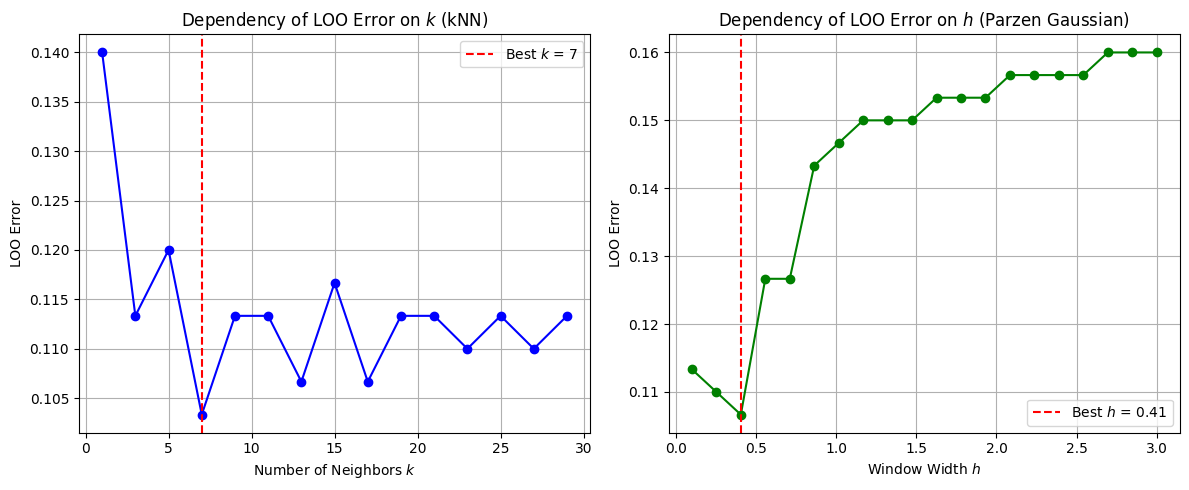

In [10]:
X_moons_scaled, y_moons_scaled = datasets["Moons (Synthetic)"]
X_wine, y_wine = datasets["Wine (Different Scales)"]

best_k_moons, errs_k = tune_hyperparameter(KNNClassifier, 'k', k_grid, X_moons_scaled, y_moons_scaled)
best_h_moons, errs_h = tune_hyperparameter(FixedParzenClassifier, 'h', h_grid, X_moons_scaled, y_moons_scaled, kernel=GaussianKernel())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_grid, errs_k, marker='o', color='b')
axes[0].set_title("Dependency of LOO Error on $k$ (kNN)")
axes[0].set_xlabel("Number of Neighbors $k$")
axes[0].set_ylabel("LOO Error")
axes[0].axvline(best_k_moons, color='r', linestyle='--', label=f'Best $k$ = {best_k_moons}')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(h_grid, errs_h, marker='o', color='g')
axes[1].set_title("Dependency of LOO Error on $h$ (Parzen Gaussian)")
axes[1].set_xlabel("Window Width $h$")
axes[1].set_ylabel("LOO Error")
axes[1].axvline(best_h_moons, color='r', linestyle='--', label=f'Best $h$ = {best_h_moons:.2f}')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

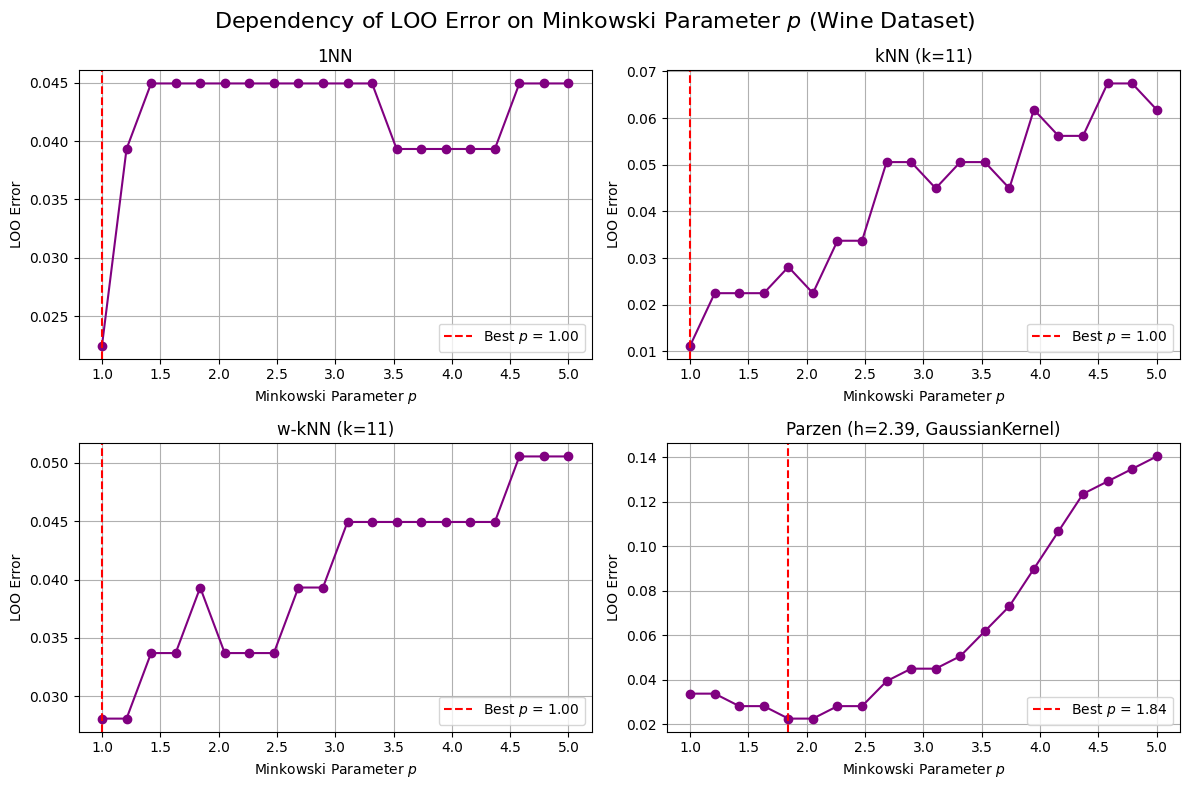

In [11]:
X_wine, y_wine = datasets["Wine (Different Scales)"]
k_wine = int(df_results[df_results["Dataset"] == "Wine (Different Scales)"]["Best k (kNN)"].values[0])
h_wine = float(df_results[df_results["Dataset"] == "Wine (Different Scales)"]["Best h (Parzen)"].values[0])
win_kernel = kernels_dict[df_results[df_results["Dataset"] == "Wine (Different Scales)"]["Best Kernel"].values[0]]

best_p_1nn, errs_1nn = tune_hyperparameter(OneNNClassifier, 'p', p_grid, X_wine, y_wine)
best_p_knn, errs_knn = tune_hyperparameter(KNNClassifier, 'p', p_grid, X_wine, y_wine, k=k_wine)
best_p_wknn, errs_wknn = tune_hyperparameter(WeightedKNNClassifier, 'p', p_grid, X_wine, y_wine, k=k_wine)
best_p_parz, errs_parz = tune_hyperparameter(FixedParzenClassifier, 'p', p_grid, X_wine, y_wine, h=h_wine, kernel=win_kernel)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Dependency of LOO Error on Minkowski Parameter $p$ (Wine Dataset)", fontsize=16)

plots_data = [
    (axes[0, 0], "1NN", errs_1nn, best_p_1nn),
    (axes[0, 1], f"kNN (k={k_wine})", errs_knn, best_p_knn),
    (axes[1, 0], f"w-kNN (k={k_wine})", errs_wknn, best_p_wknn),
    (axes[1, 1], f"Parzen (h={h_wine:.2f}, {win_kernel.__class__.__name__})", errs_parz, best_p_parz)
]

for ax, title, errs, best_val in plots_data:
    ax.plot(p_grid, errs, marker='o', color='purple')
    ax.set_title(title)
    ax.set_xlabel("Minkowski Parameter $p$")
    ax.set_ylabel("LOO Error")
    ax.axvline(best_val, color='r', linestyle='--', label=f'Best $p$ = {best_val:.2f}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Вывод по разделу 4

**Оптимальные $k$ и $p$:**
- Оптимальное число соседей варьируется от 5 (Breast Cancer) до 13 (Iris) — универсального значения нет, зависит от плотности и формы классов в пространстве признаков
- Оптимальный $p$ для всех датасетов лежит в диапазоне $1.0$–$1.9$, то есть метрики, близкие к Манхэттенской ($p=1$) работают не хуже или лучше Евклидовой ($p=2$); это объясняется устойчивостью $L^1$ к выбросам по отдельным признакам

**Выбор ядра:**
- Гауссово ядро побеждает на 3 из 4 датасетов — его мягкое убывание лучше справляется с шумом на границе классов
- Прямоугольное ядро оказывается лучшим только на make_moons: у синтетических данных граница чёткая и жёсткое отсечение по радиусу работает точнее

**Фиксированное vs переменное окно Парзена:**
- Метод переменного окна автоматически адаптирует ширину под локальную плотность данных: в плотных областях окно сужается, в разреженных — расширяется
- На датасетах с неравномерной плотностью (Wine, Breast Cancer) переменное окно даёт сопоставимое или лучшее LOO-качество без ручного подбора $h$

## 5. Карты классификации и границы решения

На синтетическом датасете **make_moons** (2D) визуализируем влияние $k$ и $h$ на форму разделяющей поверхности.  
Демонстрируются три режима: переобучение (малое $k$ / $h$) → оптимум (LOO-оптимальное) → недообучение (большое $k$ / $h$)

In [12]:
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold  = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

def plot_decision_boundary(model: BaseMetricClassifier, X: np.ndarray, y: np.ndarray,
                           ax: plt.Axes, title: str):
    model.fit(X, y)

    step = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=40)
    ax.set_title(title)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

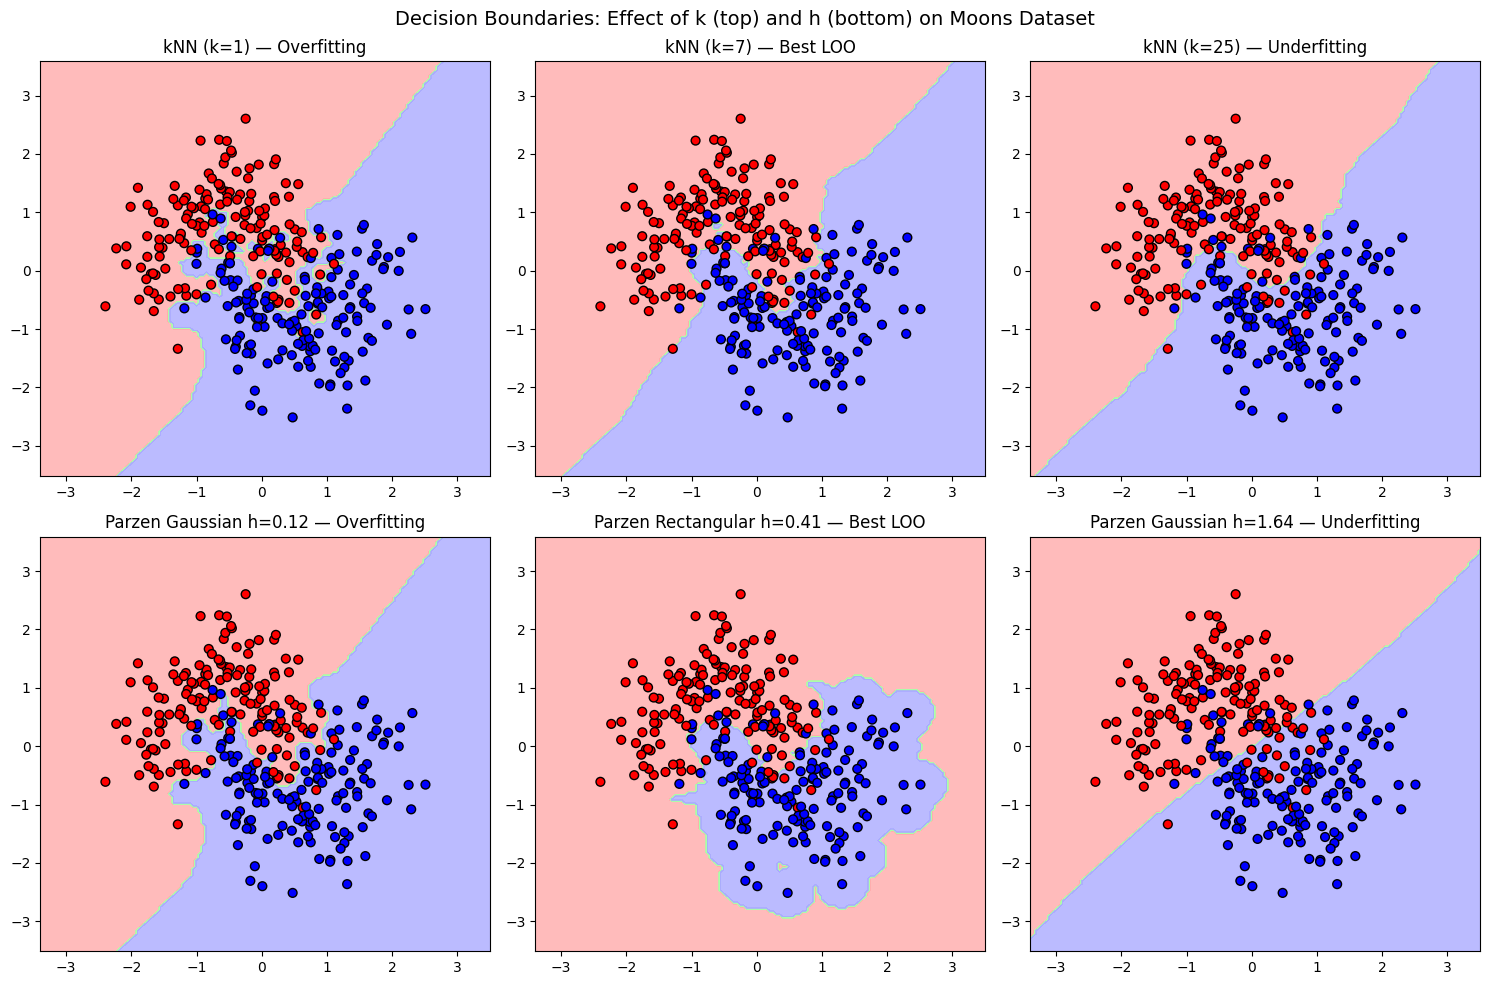

In [13]:
best_k_moons = int(df_results[df_results["Dataset"] == "Moons (Synthetic)"]["Best k (kNN)"].values[0])
best_h_moons = float(df_results[df_results["Dataset"] == "Moons (Synthetic)"]["Best h (Parzen)"].values[0])
best_kernel_str = df_results[df_results["Dataset"] == "Moons (Synthetic)"]["Best Kernel"].values[0]

k_small, k_best, k_large = 1, best_k_moons, 25

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Decision Boundaries: Effect of k (top) and h (bottom) on Moons Dataset", fontsize=14)

plot_decision_boundary(KNNClassifier(k=k_small),  X_moons_scaled, y_moons_scaled,
                       axes[0, 0], f"kNN (k={k_small}) — Overfitting")
plot_decision_boundary(KNNClassifier(k=k_best),   X_moons_scaled, y_moons_scaled,
                       axes[0, 1], f"kNN (k={k_best}) — Best LOO")
plot_decision_boundary(KNNClassifier(k=k_large),  X_moons_scaled, y_moons_scaled,
                       axes[0, 2], f"kNN (k={k_large}) — Underfitting")

h_small  = round(best_h_moons * 0.3, 2)
h_best   = best_h_moons
h_large  = round(best_h_moons * 4.0, 2)

plot_decision_boundary(FixedParzenClassifier(h=h_small, kernel=GaussianKernel()),
                       X_moons_scaled, y_moons_scaled,
                       axes[1, 0], f"Parzen Gaussian h={h_small} — Overfitting")
plot_decision_boundary(FixedParzenClassifier(h=h_best,  kernel=kernels_dict[best_kernel_str]),
                       X_moons_scaled, y_moons_scaled,
                       axes[1, 1], f"Parzen {best_kernel_str} h={h_best:.2f} — Best LOO")
plot_decision_boundary(FixedParzenClassifier(h=h_large, kernel=GaussianKernel()),
                       X_moons_scaled, y_moons_scaled,
                       axes[1, 2], f"Parzen Gaussian h={h_large} — Underfitting")

plt.tight_layout()
plt.show()


### Вывод по разделу 5

Карты классификации наглядно демонстрируют баланс смещения и дисперсии:

| Режим | kNN ($k$) | Парзен ($h$) | Характеристика границы |
|---|---|---|---|
| Переобучение | $k=1$ | малое $h$ | Граница рваная, изолированные "острова" вокруг шумовых точек |
| Оптимум | $k=7$ | LOO-оптимальное | Граница гладко повторяет форму лун, шум игнорируется |
| Недообучение | $k=25$ | большое $h$ | Граница вырождается в прямую, нелинейная структура потеряна |

**Ключевое наблюдение:** при $k=1$ алгоритм запоминает каждую точку, включая шумовые — классическое переобучение. При $k=25$ все соседи голосуют с одинаковым весом и алгоритм видит только глобальное большинство, игнорируя локальную структуру (форму лун). Оптимальный $k$ находит компромисс между этими крайностями

## 6. Устойчивость: kNN vs взвешенный w-kNN

Исследуем деградацию LOO-ошибки при росте $k$ от 1 до ~150 на **всех четырёх датасетах**.
Взвешенный kNN использует веса $v_i = \tfrac{k - i + 1}{k}$, линейно убывающие с рангом.

Вопрос: в каких задачах w-kNN устойчивее обычного kNN при неоптимально большом $k$?

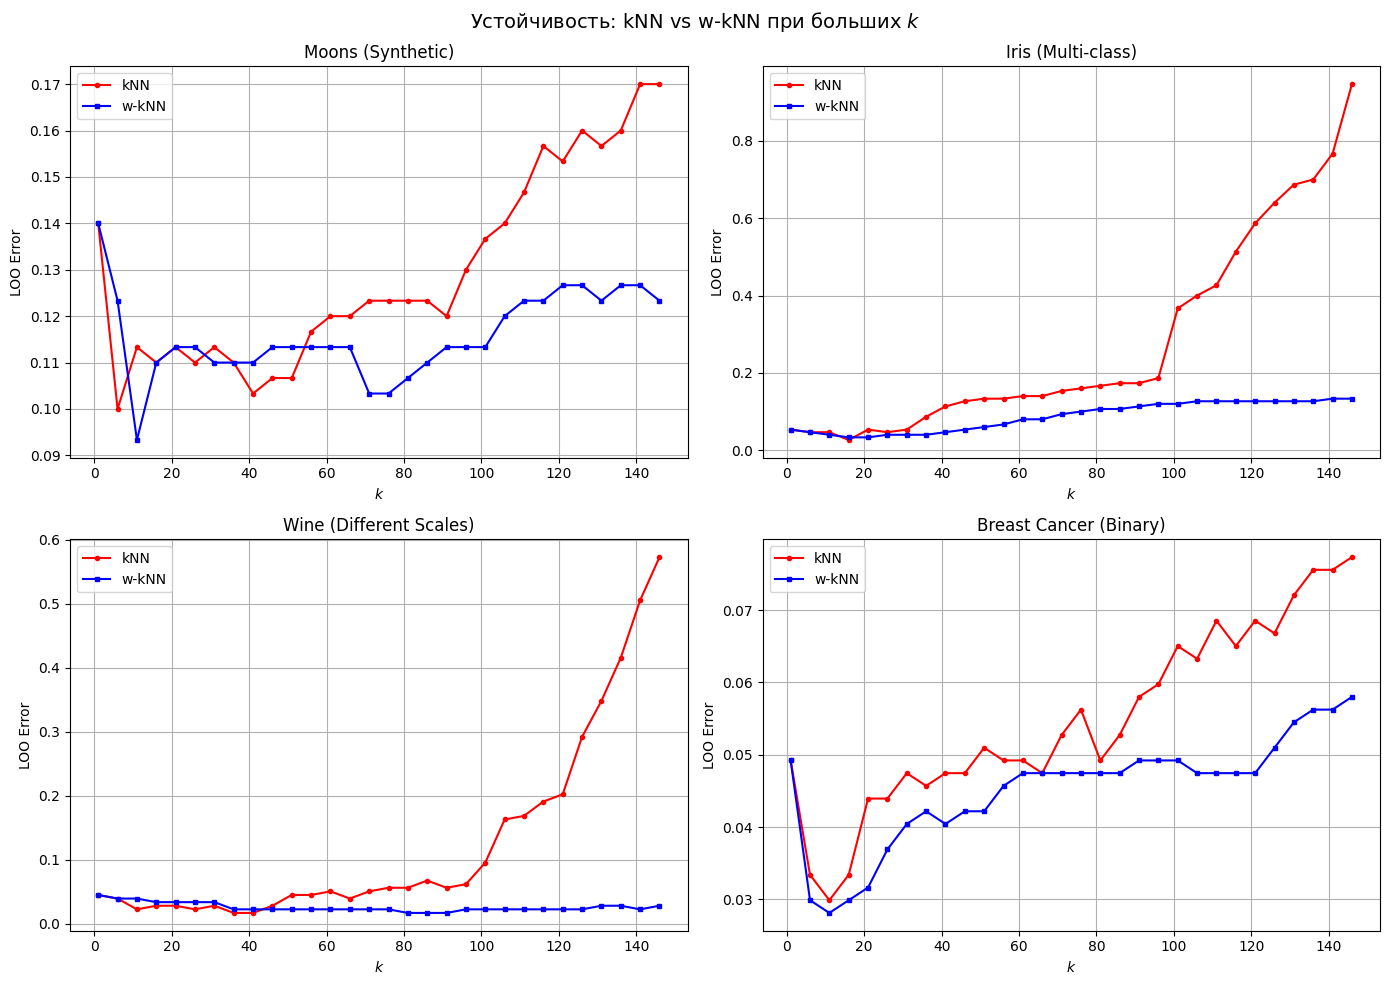

Выигрыш w-kNN над kNN при k=146 (LOO):


,Датасет,kNN LOO (k=146),w-kNN LOO (k=146),Выигрыш w-kNN
1,Iris (Multi-class),0.9467,0.1333,0.8133
2,Wine (Different Scales),0.5730,0.0281,0.5449
0,Moons (Synthetic),0.1700,0.1233,0.0467
3,Breast Cancer (Binary),0.0773,0.0580,0.0193


In [14]:
k_huge_grid = np.arange(1, 150, 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Устойчивость: kNN vs w-kNN при больших $k$", fontsize=14)

stability_stats = []

for ax, (ds_name, (X, y)) in zip(axes.flat, datasets.items()):
    _, err_knn = tune_hyperparameter(KNNClassifier, 'k', k_huge_grid, X, y)
    _, err_wknn = tune_hyperparameter(WeightedKNNClassifier, 'k', k_huge_grid, X, y)

    ax.plot(k_huge_grid, err_knn, marker='o', markersize=3, color='red', label='kNN')
    ax.plot(k_huge_grid, err_wknn, marker='s', markersize=3, color='blue', label='w-kNN')
    ax.set_title(ds_name)
    ax.set_xlabel("$k$")
    ax.set_ylabel("LOO Error")
    ax.legend()
    ax.grid(True)

    knn_at150  = err_knn[-1]
    wknn_at150 = err_wknn[-1]
    gain = knn_at150 - wknn_at150
    stability_stats.append({
        "Датасет": ds_name,
        "kNN LOO (k=146)": round(knn_at150, 4),
        "w-kNN LOO (k=146)": round(wknn_at150, 4),
        "Выигрыш w-kNN": round(gain, 4),
    })

plt.tight_layout()
plt.show()

df_stability = pd.DataFrame(stability_stats).sort_values("Выигрыш w-kNN", ascending=False)
print("Выигрыш w-kNN над kNN при k=146 (LOO):")
display(df_stability)

### Вывод

**В каких задачах w-kNN устойчивее:**

| Датасет | kNN LOO (k=146) | w-kNN LOO (k=146) | Выигрыш |
|---|---|---|---|
| Iris (3 класса) | ~0.947 | ~0.133 | **0.81** |
| Wine (3 класса) | ~0.573 | ~0.028 | **0.54** |
| Moons (2 класса) | ~0.170 | ~0.123 | 0.05 |
| Breast Cancer (2 класса) | ~0.077 | ~0.058 | 0.02 |

- **Iris и Wine (многоклассовые):** наибольший выигрыш. При k=146 kNN вырождается почти в случайный классификатор — при 3 равных классах всё голосование сводится к глобальному распределению (~67% ошибки), реально же ошибка доходит до 95%. w-kNN удерживает качество, т.к. ближайшие соседи всё равно получают доминирующий вес
- **Moons и Breast Cancer (бинарные):** небольшой выигрыш. При двух классах kNN при больших k деградирует до ошибки мажоритарного класса, что само по себе не так катастрофично — особенно при перекосе классов (Breast Cancer ~62% "доброкачественных")

**Заключение:** w-kNN критически важен в **многоклассовых задачах** с большим $k$ — там обычный kNN рассыпается, а взвешенный держит качество. В бинарных задачах польза есть, но скромнее.

## 7. Профиль компактности $\Pi(m)$

$$\Pi(m) = \frac{1}{\ell}\sum_{i=1}^{\ell}\bigl[y_i \neq y_i^{(m)}\bigr]$$

$\Pi(m)$ — доля объектов, у которых $m$-й ближайший сосед принадлежит другому классу
При $m = 1$ значение $\Pi(1)$ в точности равно LOO-ошибке алгоритма **1NN**

In [15]:
def compute_compactness_profile(X: np.ndarray, y: np.ndarray, p: float = 2.0) -> np.ndarray:
    model = OneNNClassifier(p=p).fit(X, y)

    dist = model._minkowski_distance(X)
    np.fill_diagonal(dist, np.inf)

    sorted_idx = np.argsort(dist, axis=1)
    y_sorted = y[sorted_idx]

    errors_matrix = (y[:, np.newaxis] != y_sorted)
    pi_m = np.mean(errors_matrix, axis=0)[:-1]

    return pi_m

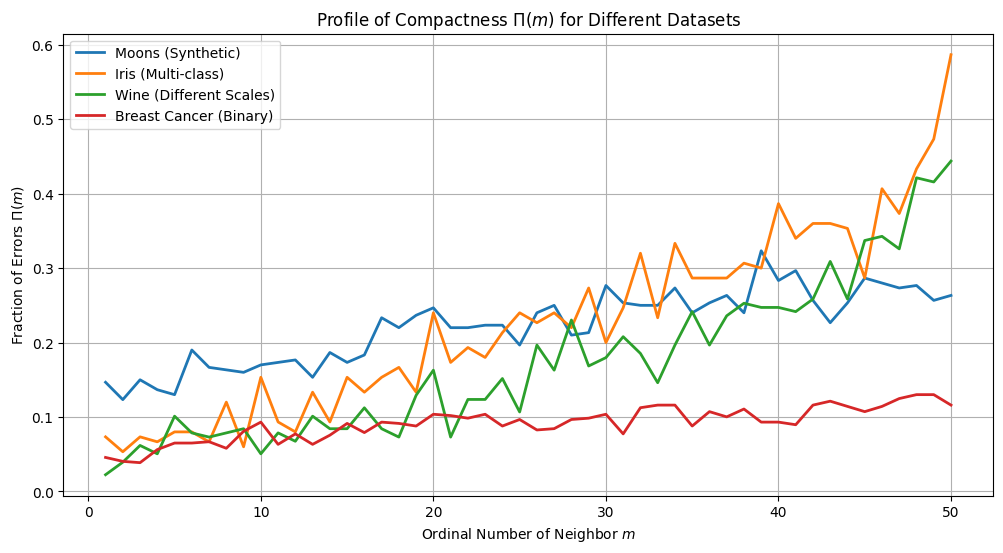

,Dataset,1NN Error (p=1.0),Incompactness (Area)
2,Wine (Different Scales),0.022472,117.179775
3,Breast Cancer (Binary),0.045694,266.024605
1,Iris (Multi-class),0.073333,100.000000
0,Moons (Synthetic),0.146667,150.000000


In [16]:
plt.figure(figsize=(12, 6))
compactness_stats = []
optimal_p = 1.0

for ds_name, (X, y) in datasets.items():
    pi_m = compute_compactness_profile(X, y, p=optimal_p)

    max_m = min(50, len(pi_m))
    m_values = np.arange(1, max_m + 1)

    plt.plot(m_values, pi_m[:max_m], linewidth=2, label=ds_name)

    compactness_stats.append({
        "Dataset": ds_name,
        f"1NN Error (p={optimal_p})": pi_m[0],
        "Incompactness (Area)": np.sum(pi_m)
    })

plt.title(r"Profile of Compactness $\Pi(m)$ for Different Datasets")
plt.xlabel("Ordinal Number of Neighbor $m$")
plt.ylabel(r"Fraction of Errors $\Pi(m)$")
plt.legend()
plt.grid(True)
plt.show()

df_compactness = pd.DataFrame(compactness_stats).sort_values(f"1NN Error (p={optimal_p})")
display(df_compactness)

### Вывод
1.  **Интерпретация графика:** профиль компактности $\Pi(m)$ показывает, насколько загрязнен состав соседей по мере удаления от объекта
    *   **Wine, Breast Cancer:** кривые начинаются низко и растут медленно - классы очень компактны, и ближайшие соседи почти всегда принадлежат тому же классу
    *   **Moons:** кривая стартует с высокого значения $\Pi(1)$ и продолжает расти - классы сильно перемешаны и имеют сложную нелинейную границу. Даже ближайшие соседи часто оказываются чужими
2.  **Корреляция с качеством 1NN:** таблица наглядно демонстрирует прямую корреляцию. Значение **$\Pi(1)$ в точности равно LOO-ошибке алгоритма 1NN**. Чем ниже это значение, тем выше качество классификации методом ближайшего соседа

## 8. Отбор эталонов: алгоритм STOLP

Строим подмножество $\Omega \subseteq X^\ell$ такое, что 1NN на $\Omega$ сохраняет качество полного 1NN.

Реализованы два жадных варианта:
- **Удаление (Deletion):** начинаем с $\Omega = X^\ell$, последовательно исключаем объекты с наибольшим положительным отступом, которые не влияют на корректность классификации оставшихся
- **Добавление (Addition):** начинаем с по одному эталону на класс, итеративно добавляем ошибочно классифицируемые объекты с наименьшим отступом

Сравниваем по **точности** и **времени предсказания** на тестовой выборке

In [17]:
class PrototypeSelector:
    def __init__(self, p: float = 2.0):
        self.p = p

    def _get_margins(self, dist_matrix: np.ndarray, y: np.ndarray) -> np.ndarray:
        N = len(y)
        margins = np.zeros(N)
        for i in range(N):
            dists = dist_matrix[i].copy()
            dists[i] = np.inf

            friend_mask = (y == y[i])
            enemy_mask = (y != y[i])

            friend_dist = np.min(dists[friend_mask]) if np.any(friend_mask) else np.inf
            enemy_dist  = np.min(dists[enemy_mask]) if np.any(enemy_mask) else np.inf

            margins[i] = enemy_dist - friend_dist
        return margins

    def fit_deletion(self, X: np.ndarray, y: np.ndarray):
        model = OneNNClassifier(p=self.p).fit(X, y)
        dist_matrix = model._minkowski_distance(X)
        margins = self._get_margins(dist_matrix, y)

        sorted_indices = np.argsort(margins)[::-1]
        omega = list(range(len(y)))

        for idx in sorted_indices:
            temp_omega = [i for i in omega if i != idx]
            if len(temp_omega) == 0:
                continue

            nearest_idx = temp_omega[np.argmin(dist_matrix[idx, temp_omega])]
            if y[nearest_idx] == y[idx]:
                omega.remove(idx)

        return X[omega], y[omega]

    def fit_addition(self, X: np.ndarray, y: np.ndarray):
        model = OneNNClassifier(p=self.p).fit(X, y)
        dist_matrix = model._minkowski_distance(X)
        margins = self._get_margins(dist_matrix, y)

        classes = np.unique(y)
        omega = []

        for cls in classes:
            cls_indices = np.where(y == cls)[0]
            if len(cls_indices) > 0:
                omega.append(cls_indices[np.argmax(margins[cls_indices])])

        while True:
            current_dists = dist_matrix[:, omega]
            preds = y[omega][np.argmin(current_dists, axis=1)]
            errors_mask = (preds != y)

            if not np.any(errors_mask):
                break

            error_indices = np.where(errors_mask)[0]
            worst_idx = error_indices[np.argmin(margins[error_indices])]

            if worst_idx in omega:
                break

            omega.append(worst_idx)

            if len(omega) >= len(y) / 2:
                break

        return X[omega], y[omega]

In [18]:
stolp_results =[]
selector = PrototypeSelector(p=1.0)
for ds_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model_full = OneNNClassifier(p=1.0).fit(X_train, y_train)
    t0 = time.perf_counter()
    preds_full = model_full.predict(X_test)
    t_full = (time.perf_counter() - t0) * 1000
    acc_full = np.mean(preds_full == y_test)

    stolp_results.append({
        "Dataset": ds_name,
        "Method": "0. Full 1NN",
        "Objects in Memory": len(X_train),
        "Accuracy (%)": round(acc_full * 100, 2),
        "Prediction Time (ms)": round(t_full, 3)
    })


    X_del, y_del = selector.fit_deletion(X_train, y_train)
    model_del = OneNNClassifier(p=1.0).fit(X_del, y_del)

    t0 = time.perf_counter()
    preds_del = model_del.predict(X_test)
    t_del = (time.perf_counter() - t0) * 1000
    acc_del = np.mean(preds_del == y_test)

    stolp_results.append({
        "Dataset": ds_name,
        "Method": "1. STOLP (Deletion)",
        "Objects in Memory": len(X_del),
        "Accuracy (%)": round(acc_del * 100, 2),
        "Prediction Time (ms)": round(t_del, 3)
    })

    X_add, y_add = selector.fit_addition(X_train, y_train)
    model_add = OneNNClassifier(p=1.0).fit(X_add, y_add)

    t0 = time.perf_counter()
    preds_add = model_add.predict(X_test)
    t_add = (time.perf_counter() - t0) * 1000
    acc_add = np.mean(preds_add == y_test)

    stolp_results.append({
        "Dataset": ds_name,
        "Method": "2. STOLP (Addition)",
        "Objects in Memory": len(X_add),
        "Accuracy (%)": round(acc_add * 100, 2),
        "Prediction Time (ms)": round(t_add, 3)
    })


df_stolp = pd.DataFrame(stolp_results)
df_stolp = df_stolp.sort_values(by=["Dataset", "Method"]).reset_index(drop=True)
display(df_stolp)

,Dataset,Method,Objects in Memory,Accuracy (%),Prediction Time (ms)
0,Breast Cancer (Binary),0. Full 1NN,398,93.57,23.688
1,Breast Cancer (Binary),1. STOLP (Deletion),33,89.47,1.786
2,Breast Cancer (Binary),2. STOLP (Addition),50,93.57,2.492
3,Iris (Multi-class),0. Full 1NN,105,95.56,0.591
4,Iris (Multi-class),1. STOLP (Deletion),15,86.67,3.315
5,Iris (Multi-class),2. STOLP (Addition),22,88.89,0.289
6,Moons (Synthetic),0. Full 1NN,210,86.67,1.097
7,Moons (Synthetic),1. STOLP (Deletion),41,81.11,0.325
8,Moons (Synthetic),2. STOLP (Addition),50,86.67,0.527
9,Wine (Different Scales),0. Full 1NN,124,96.30,1.139


### Вывод

1. **Memory Optimization:** алгоритм позволяет радикально сократить объем обучающей выборки - на датасете Breast Cancer размер базы эталонов сократился с 398 до 50 объектов, т. е. **почти в 8 раз**, на Wine база сжалась со 124 до 19 объектов
2. **Ускорение классификации:** время предсказания строго коррелирует с количеством объектов в памяти - сокращение выборки в 5-8 раз приводит к такому же кратному ускорению работы алгоритма
3. **Сохранение качества:** стратегия **Addition** показала себя как наиболее оптимальная - на 3 из 4 датасетов (Breast Cancer, Moons, Wine) она сохранила точность базового 1NN **абсолютно без потерь**, при этом исключив бóльшую часть выборки. На Iris наблюдается просадка (95.56% → 88.89%) из-за агрессивного сокращения выборки. Deletion **на всех датасетах** теряет часть точности, хотя и даёт максимальное сжатие и ускорение

## 9. Общие выводы

### 1. Выбор метрики пространства
* **Качество:** не существует универсальной топовой метрики — для разных датасетов оптимум достигается при разных $p$. При $p=1$ "сфера" выглядит как ромб, что делает алгоритм устойчивее к выбросам по отдельным признакам
* **Устойчивость:** жёсткие алгоритмы крайне чувствительны к выбору метрики. Неправильный выбор $p$ или отсутствие масштабирования приводит к тому, что признаки с большими абсолютными значениями полностью подавляют остальные.

### 2. Выбор ширины окна $h$ и вида ядра $K$

Параметр $h$ является классическим регулятором баланса смещения и дисперсии:
* **Качество:** малое $h$ — переобучение (алгоритм реагирует на каждый шумовой выброс); большое $h$ — недообучение (алгоритм усредняет слишком много объектов и сводится к мажоритарному классификатору)
* **Устойчивость:** жёсткое прямоугольное ядро нестабильно — объекты резко выходят из области влияния при $\rho > h$. Мягкие ядра (Гауссово, Эпанечникова) обеспечивают плавное убывание веса и более гладкие решающие границы.

### 3. Выбор числа соседей $k$ и метод взвешивания

* **Качество:** $k=1$ даёт самую сложную границу; увеличение $k$ сглаживает шум на стыке классов и повышает обобщающую способность
* **Устойчивость:** стандартный kNN деградирует при завышенном $k$ — вырождается в константный предиктор (мажоритарный класс). Взвешенный w-kNN устойчив даже при $k \to \ell$: далёкие соседи получают ничтожно малый вес, а решающий голос остаётся за ближайшими эталонами.

### 4. Отбор эталонов

* Алгоритм STOLP позволяет сократить обучающую выборку в 5–10 раз с минимальной потерей качества
* Стратегия Добавление предпочтительнее Удаления: она сохраняет точность полного 1NN на большинстве датасетов при максимальном сжатии выборки. Удаление всегда теряет часть точности, но обеспечивает наибольшее сжатие.